> **Archive du TIPE (2024-25).** Ce notebook est le carnet de travail d'origine, conservé avec ses sorties. Le code a depuis été rangé dans `segmentation/`, `train.py` et `evaluate.py` : c'est cette version qu'il faut utiliser. Les chemins de fichiers ci-dessous correspondent à l'ancienne organisation du dépôt.

# Création d'une IA pytorch pour créer des seeds


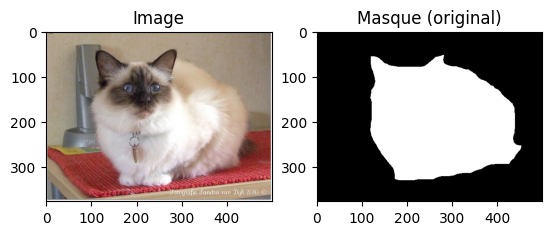

In [2]:
# torch
import torch
from torchvision.datasets import OxfordIIITPet
import torchvision.transforms as T
from torch.utils.data import Dataset, Subset
from torchvision.transforms import ToTensor, Resize, Compose
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm
from torchvision.transforms.functional import InterpolationMode


# autre
import matplotlib.pyplot as plt
import numpy as np
import random
from random import randint
import cv2
import os
from PIL import Image


# Chargement du dataset
dataset = OxfordIIITPet(root='data/pets', download=True, target_types='segmentation')

# Exemple : récupérer une image + son masque
img, mask = dataset[randint(0,1000)]

np_mask = np.array(mask)             # Convertit le masque PIL en tableau numpy
binary_mask = (np_mask == 1).astype(np.uint8)

# Affichage de l’image
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Image")

# Affichage du masque
plt.subplot(1, 2, 2)
plt.imshow(binary_mask, cmap='gray')
plt.title("Masque (original)")
plt.show()

In [3]:
# Races de chats
CAT_CLASSES = [
    'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair',
    'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll',
    'Russian_Blue', 'Siamese', 'Sphynx'
]

class OxfordPetCatsOnly(Dataset):
    def __init__(self, root='data/pets', image_size=(256, 256), radius=5):
        self.full_dataset = OxfordIIITPet(root=root, download=True, target_types='segmentation')
        self.image_size = image_size
        self.radius = radius

        self.img_transform = T.Compose([
            T.Resize(image_size),
            T.ToTensor()
        ])
        self.mask_transform = T.Resize(image_size, interpolation=InterpolationMode.NEAREST)

        # Garde les images de chats uniquement
        self.indices = []
        for i in range(len(self.full_dataset)):
            filename = os.path.basename(self.full_dataset._images[i])
            class_name = filename.split('_')[0]
            if class_name in CAT_CLASSES:
                self.indices.append(i)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, mask = self.full_dataset[real_idx]

        # Transformations
        image = self.img_transform(image)
        mask = self.mask_transform(mask)

        np_mask = np.array(mask)  # -> [H, W], avec valeurs 0, 1, 2
        binary_mask = (np_mask == 1).astype(np.uint8)

        # Génération des seeds par érosion
        kernel = np.ones((self.radius, self.radius), np.uint8)
        fg = cv2.erode(binary_mask, kernel, iterations=2)
        bg = cv2.erode(1 - binary_mask, kernel, iterations=2)

        seed_map = np.full(binary_mask.shape, -1, dtype=np.int64)
        seed_map[fg == 1] = 1
        seed_map[bg == 1] = 0

        return image, torch.from_numpy(seed_map), torch.from_numpy(binary_mask)

In [9]:
full_dataset = OxfordPetCatsOnly()
train_size = int(0.8 * len(full_dataset))

# divise en deux ensembles training et val en assurant un tirage uniforme des races avec random.shuffle()
indices = list(range(len(full_dataset)))
random.seed(42)  # pour reproductibilité
random.shuffle(indices)

train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = Subset(full_dataset, train_indices)
val_dataset = Subset(full_dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [5]:
print(len(val_dataset))
print(len(train_dataset))
print(train_size)

159
636
636


In [6]:
class MiniSeedNet(nn.Module):
    def __init__(self):
        super(MiniSeedNet, self).__init__()
        self.encoder = nn.Sequential(        # l'encodeur apprend à garder les informations importantes
            nn.Conv2d(3, 16, 3, padding=1),  # -> [B, 16, 256, 256]  couche convolutive : extrait les motifs locaux
            nn.ReLU(),
            nn.MaxPool2d(2),                 # -> [B, 16, 128, 128] # divise la taille de l'image en 2 en découpant en 2*2 et gardant pixel plus grande valeur
            
            nn.Conv2d(16, 32, 3, padding=1), # -> [B, 32, 128, 128]
            nn.ReLU(),
            nn.MaxPool2d(2),                 # -> [B, 32, 64, 64]
        )

        self.decoder = nn.Sequential(         # le décodeur restitue une carte des seeds à la même taille que l'image
            nn.ConvTranspose2d(32, 16, 2, stride=2), # -> [B, 16, 128, 128]
            nn.ReLU(),
            nn.ConvTranspose2d(16, 16, 2, stride=2), # -> [B, 16, 256, 256]
            nn.ReLU(),
            nn.Conv2d(16, 2, 1)                      # -> [B, 2, 256, 256]  B = batchsize   2 = canaux de sortie (fond(0)/objet(1))   (256,256) h*w
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x  # logits pour chaque classe 
    


In [7]:
model = MiniSeedNet()
dummy_input = torch.randn(4, 3, 256, 256)  # batch de 4 images
output = model(dummy_input)
print(output.shape)  # → [4, 2, 256, 256]

torch.Size([4, 2, 256, 256])


In [ ]:
"""criterion = nn.CrossEntropyLoss(ignore_index=-1)  # Ignore les pixels non-labelisés

def train(model, dataloader, device='cuda', epochs=5, lr=1e-3):
    model = model.to(device)
    weights = torch.tensor([1.0, 5.0]).to(device)  # [poids pour 0, poids pour 1]
    criterion = nn.CrossEntropyLoss(ignore_index=-1, weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for images, seed_maps, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            images = images.to(device)
            seed_maps = seed_maps.to(device)

            outputs = model(images)  # [B, 2, 256, 256]
            loss = criterion(outputs, seed_maps)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"🔁 Epoch {epoch+1} — Loss: {epoch_loss / len(dataloader):.4f}")"""

In [30]:
import csv
import os

def get_last_session_number(csv_path="losses.csv"):
    if not os.path.exists(csv_path):
        print("⚠️  Fichier CSV introuvable.")
        return None

    last_session = 0
    with open(csv_path, mode='r', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            try:
                session = int(row["Session"])
                last_session = max(last_session, session)
            except (KeyError, ValueError):
                continue  # Ignore les lignes mal formées

    return last_session if last_session > 0 else None

def save_losses_to_csv(train_losses, val_losses, filename="losses.csv"):
    file_exists = os.path.exists(filename)

    # Récupère la dernière session et incrémente
    last_session = get_last_session_number(filename)
    session_number = (last_session or 0) + 1

    with open(filename, mode="a", newline="") as f:
        writer = csv.writer(f)

        if not file_exists:
            writer.writerow(["Session", "Epoch", "Train Loss", "Validation Loss"])

        for i, (train_l, val_l) in enumerate(zip(train_losses, val_losses), 1):
            writer.writerow([session_number, i, train_l, val_l])



In [ ]:
def train(model, train_loader, val_loader, device='cuda', epochs=5, lr=1e-3):
    # Envoi du modèle sur le GPU ou CPU
    model = model.to(device)

    # Définition des poids pour chaque classe (ex : objet vs fond), utile en cas de déséquilibre
    weights = torch.tensor([1.0, 5.0]).to(device)
    criterion = nn.CrossEntropyLoss(ignore_index=-1, weight=weights)  # -1 = pixels ignorés
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Optimiseur Adam

    # Listes pour stocker les pertes par époque
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()  # Mode entraînement
        epoch_loss = 0.0
        
        # Boucle sur les batches d'entraînement
        for images, seed_maps, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            # Passage des données sur le device
            images = images.to(device)
            seed_maps = seed_maps.to(device)

            # Prédiction du modèle
            outputs = model(images)

            # Calcul de la perte (comparaison prédictions vs étiquettes)
            loss = criterion(outputs, seed_maps)

            # Rétropropagation du gradient et mise à jour des poids
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Accumulation de la perte sur l'époque
            epoch_loss += loss.item()

        # Moyenne des pertes d'entraînement sur l'époque
        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ------------------------------
        # Phase d'évaluation sur validation
        model.eval()  # Mode évaluation (désactive dropout, batchnorm)
        val_loss = 0.0
        with torch.no_grad():  # Pas de calcul de gradient ici
            for images, seed_maps, _ in val_loader:
                images = images.to(device)
                seed_maps = seed_maps.to(device)

                outputs = model(images)
                loss = criterion(outputs, seed_maps)
                val_loss += loss.item()

        # Moyenne des pertes de validation sur l'époque
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # Affichage du résumé de l'époque
        print(f"🔁 Epoch {epoch+1} — Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    
    # Sauvegarde des courbes de pertes dans un fichier CSV
    save_losses_to_csv(train_losses, val_losses)

In [17]:
from datetime import datetime

# train(model, train_loader, val_loader, device='cuda' if torch.cuda.is_available() else 'cpu', epochs=50)

last_session = get_last_session_number()

filename = f"seednet_session{last_session}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
torch.save(model.state_dict(), filename)

In [32]:
from datetime import datetime
filename = f"seednet_session0_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
torch.save(model.state_dict(), filename)

In [33]:
def visualize_predictions(model, dataloader, device='cuda'):
    # créé un dossier images pour suivre l'avancement de la qualité des seedmaps
    session_number = get_last_session_number("losses.csv") or 1
    output_dir = f"images_session{session_number}"
    os.makedirs(output_dir, exist_ok=True)

    model.eval()
    model = model.to(device)

    with torch.no_grad():
        for images, seed_maps, _ in dataloader:
            images = images.to(device)
            seed_maps = seed_maps.to(device)

            outputs = model(images)  # [B, 2, H, W]
            probs = F.softmax(outputs, dim=1)

            fg_probs = probs[:, 1]  # foreground prob
            bg_probs = probs[:, 0]  # background prob

            # Seuiler les *seeds* prédits (proba > 0.9)
            pred_seed_map = torch.full_like(seed_maps, -1)
            pred_seed_map[fg_probs > 0.8] = 1
            pred_seed_map[bg_probs > 0.8] = 0

            # Afficher les 4 premiers exemples
            for i in range(4):
                plt.figure(figsize=(12, 3))

                plt.subplot(1, 3, 1)
                plt.imshow(images[i].cpu().permute(1, 2, 0))
                plt.title("Image")

                plt.subplot(1, 3, 2)
                plt.imshow(seed_maps[i].cpu(), cmap='jet', vmin=-1, vmax=1)
                plt.title("Seed Map Cible")

                plt.subplot(1, 3, 3)
                plt.imshow(pred_seed_map[i].cpu(), cmap='jet', vmin=-1, vmax=1)
                plt.title("Prédiction Seed Map")

                    # 🖼️ Sauvegarde la figure dans le dossier
                filename = f"{output_dir}/exemple_{i+1}.png"
                plt.tight_layout()
                plt.savefig(filename)
                plt.close()
            break  # afficher juste un batch


In [55]:
from datetime import datetime

train(model, train_loader, val_loader, device='cuda' if torch.cuda.is_available() else 'cpu', epochs=50)

last_session = get_last_session_number()

filename = f"seednet_session{last_session}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
torch.save(model.state_dict(), filename)

visualize_predictions(model, val_loader, device='cuda' if torch.cuda.is_available() else 'cpu')


Epoch 1/50: 100%|██████████| 159/159 [00:04<00:00, 39.31it/s]


🔁 Epoch 1 — Train Loss: 0.4037 | Val Loss: 0.4596


Epoch 2/50: 100%|██████████| 159/159 [00:04<00:00, 35.33it/s]


🔁 Epoch 2 — Train Loss: 0.3979 | Val Loss: 0.4694


Epoch 3/50: 100%|██████████| 159/159 [00:04<00:00, 39.22it/s]


...

🔁 Epoch 48 — Train Loss: 0.4052 | Val Loss: 0.4575


Epoch 49/50: 100%|██████████| 159/159 [00:04<00:00, 35.67it/s]


🔁 Epoch 49 — Train Loss: 0.3960 | Val Loss: 0.4588


Epoch 50/50: 100%|██████████| 159/159 [00:04<00:00, 36.47it/s]


🔁 Epoch 50 — Train Loss: 0.3967 | Val Loss: 0.4540


In [ ]:
def visualize_predictions_2(model, dataloader, device='cuda'):
    model.eval()
    model = model.to(device)
    batch = 0 # compteur de batch
    w_batch = 12 # index du batch à afficher
    with torch.no_grad():
        for images, seed_maps, _ in dataloader:
            if batch == w_batch:
                images = images.to(device)
                seed_maps = seed_maps.to(device)

                outputs = model(images)  # [B, 2, H, W]
                probs = F.softmax(outputs, dim=1)

                fg_probs = probs[:, 1]  # foreground prob
                bg_probs = probs[:, 0]  # background prob

                # Seuiler les *seeds* prédits (proba > 0.85)
                pred_seed_map = torch.full_like(seed_maps, -1)
                pred_seed_map[fg_probs > 0.85] = 1
                pred_seed_map[bg_probs > 0.85] = 0

                # Afficher les 4 premiers exemples
                for i in range(4):
                    plt.figure(figsize=(12, 3))

                    plt.subplot(1, 3, 1)
                    plt.imshow(images[i].cpu().permute(1, 2, 0))
                    plt.title("Image")

                    plt.subplot(1, 3, 2)
                    plt.imshow(seed_maps[i].cpu(), cmap='jet', vmin=-1, vmax=1)
                    plt.title("Seed Map Cible")

                    plt.subplot(1, 3, 3)
                    plt.imshow(pred_seed_map[i].cpu(), cmap='jet', vmin=-1, vmax=1)
                    plt.title("Prédiction Seed Map")

                    plt.show()
                break # afficher juste un batch
            batch +=1  

In [114]:
model = MiniSeedNet()
model.load_state_dict(torch.load("seednet_session20_20250605_102609.pth"))


<All keys matched successfully>

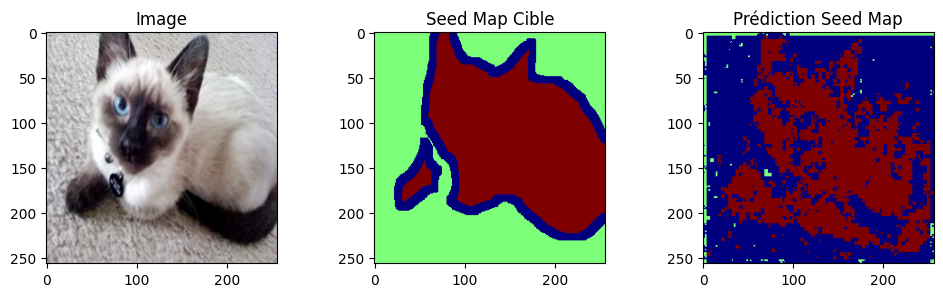

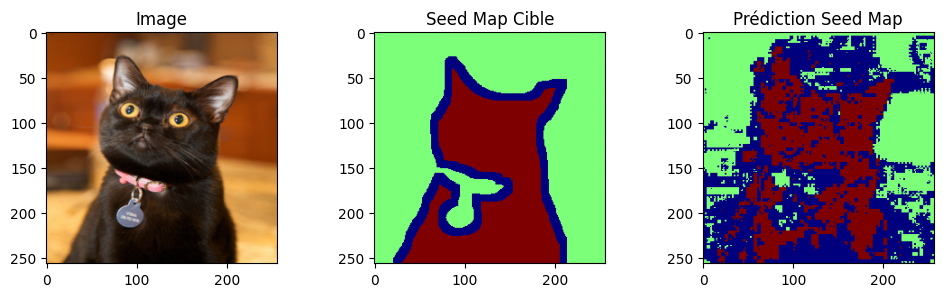

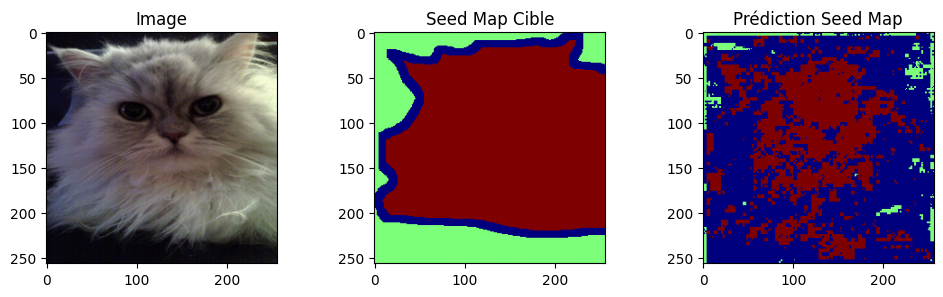

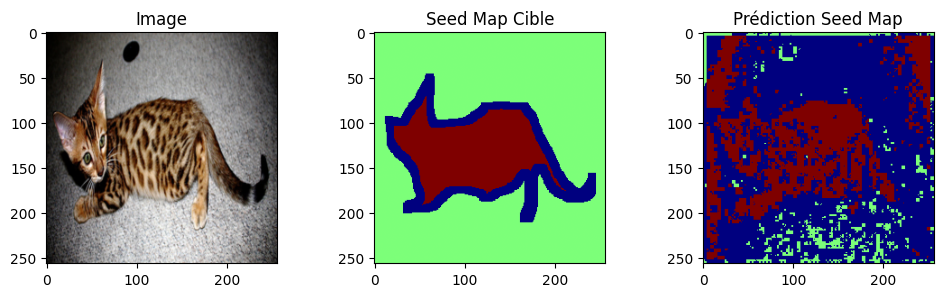

In [115]:
visualize_predictions_2(model, val_loader, device='cuda' if torch.cuda.is_available() else 'cpu')

In [62]:
def draw_disk(center_y, center_x, radius, shape):
    Y, X = np.ogrid[:shape[0], :shape[1]]
    dist = (Y - center_y)**2 + (X - center_x)**2
    mask = dist <= radius**2
    return np.where(mask)

def get_limited_seeds(fg_probs, bg_probs, n_fg=3, n_bg=3, radius=3, fg_thresh=0.9, bg_thresh=0.9):
    """
    Crée un dictionnaire de seeds[(y,x)] = label à partir des probabilités de foreground/background.
    - n_fg : nombre de seeds foreground
    - n_bg : nombre de seeds background
    """
    H, W = fg_probs.shape
    seeds = {}

    # 1. Masques binaires
    fg_mask = fg_probs > fg_thresh
    bg_mask = bg_probs > bg_thresh

    # 2. Coordonnées des candidats
    fg_coords = list(zip(*np.where(fg_mask)))
    bg_coords = list(zip(*np.where(bg_mask)))

    # 3. Sélection aléatoire de n points
    if len(fg_coords) >= n_fg:
        fg_sample = random.sample(fg_coords, n_fg)
    else:
        fg_sample = fg_coords

    if len(bg_coords) >= n_bg:
        bg_sample = random.sample(bg_coords, n_bg)
    else:
        bg_sample = bg_coords

    # 4. Remplir le dictionnaire avec des disques
    for y, x in fg_sample:
        ys, xs = draw_disk(y, x, radius, (H, W))
        for yy, xx in zip(ys, xs):
            seeds[(yy, xx)] = "#ff0000"

    for y, x in bg_sample:
        ys, xs = draw_disk(y, x, radius, (H, W))
        for yy, xx in zip(ys, xs):
            seeds[(yy, xx)] = "#00ff00"

    return seeds




In [117]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Étape 1 — récupérer une image et son masque
index = 25 # par exemple
image, _, _ = val_dataset[index]  # image: [3, 256, 256]
image = image.to(device).unsqueeze(0)  # [1, 3, 256, 256]

# Étape 2 — prédiction des probabilités
model.eval()
with torch.no_grad():
    output = model(image)  # [1, 2, H, W]
    probs = torch.softmax(output, dim=1)[0].cpu().numpy()  # [2, H, W]

fg_probs = probs[1]  # foreground
bg_probs = probs[0]  # background

# Étape 3 — appliquer la fonction de génération de seeds
seeds = get_limited_seeds(fg_probs, bg_probs, n_fg=12, n_bg=12, radius=3)

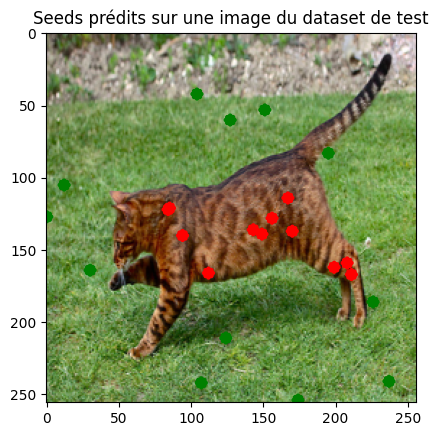

In [118]:
img_np = image.squeeze(0).permute(1, 2, 0).cpu().numpy()

img_uint8 = (img_np * 255).astype(np.uint8)


# Créer une image PIL et sauvegarder
image_pil = Image.fromarray(img_uint8)
image_pil.save(f"cat{index}.jpg")


plt.imshow(img_np)
ys, xs = zip(*seeds.keys())
plt.scatter(xs, ys, c=['green' if seeds[(y,x)]=="#00ff00" else 'red' for y,x in seeds], s=5)
plt.title("Seeds prédits sur une image du dataset de test")
plt.show()

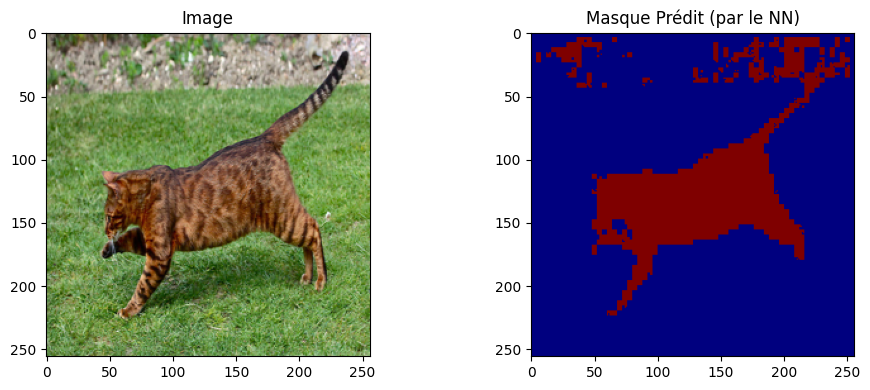

In [119]:
predicted_mask = np.argmax(probs, axis=0)

def afficher_prediction_nn(image_tensor, predicted_mask):
    image_np = image_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    image_np = np.clip(image_np, 0, 1)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image_np)
    plt.title("Image")

    plt.subplot(1, 2, 2)
    plt.imshow(predicted_mask, cmap='jet', vmin=0, vmax=1)
    plt.title("Masque Prédit (par le NN)")

    plt.tight_layout()
    plt.show()

afficher_prediction_nn(image, predicted_mask)

In [69]:
from PIL import Image, ImageTk
import json
import os
from main import UI
import tkinter as tk

In [120]:
   
# Nom du fichier unique où seront stockés tous les presets
PRESETS_FILENAME = "seeds.json"

class ImportAIseed():
    def __init__(self, seeds={}):
        # Dictionnaire local : { (y, x): '#RRGGBB' }
        self.seeds = seeds
        # Lecture du fichier JSON global des presets 
        self.all_presets = self.load_all_presets()
   
    def load_all_presets(self):
        """Charge le contenu de seeds.json (ou renvoie un dict vide si absent)."""
        if os.path.exists(PRESETS_FILENAME):
            with open(PRESETS_FILENAME, "r") as f:
                return json.load(f)  # Structure attendue: { "presetName": { "(y,x)": "#RRGGBB", ... }, ... }
        else:
            return {}

    def save_all_presets(self):
        """Sauvegarde le dictionnaire self.all_presets dans seeds.json."""
        with open(PRESETS_FILENAME, "w") as f:
            json.dump(self.all_presets, f, indent=2)
        print(f"Tous les presets ont été sauvegardés dans {PRESETS_FILENAME}.")


    def save_current_seeds_as_preset(self, preset_name):
        """Récupère le nom du preset, l’enregistre dans self.all_presets, puis réécrit seeds.json."""

        # Convertir (y, x) en str pour JSON
        seeds_str_keys = {
        str((int(y), int(x))): color
        for (y, x), color in self.seeds.items()
        }

        # Stocker dans le gros dictionnaire 
        self.all_presets[preset_name] = seeds_str_keys

        # Sauver le gros dictionnaire en JSON
        self.save_all_presets()

        print(f"Preset '{preset_name}' sauvegardé avec {len(self.seeds)} points.")


new = ImportAIseed(seeds)
preset_name = "cat" + str(index)
new.save_current_seeds_as_preset(preset_name)

Tous les presets ont été sauvegardés dans seeds.json.
Preset 'cat25' sauvegardé avec 659 points.


In [257]:
root = tk.Tk()
root.title("Sélecteur de couleur et affichage d'image")
ui = UI(root)
ui.run_ui()
root.mainloop()

Nouvelle image chargée : /home/ikseno/python_coding/tipe/images_test/cat2.jpg
